In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

In [3]:

# Load the daily data
df = pd.read_csv("day.csv")

# Preview
print(df.shape)
df.head()

(731, 16)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [5]:

# Drop unnecessary columns
df = df.drop(['instant', 'casual', 'registered'], axis=1)

# Convert categorical columns to category dtype
categorical = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit']
for col in categorical:
    df[col] = df[col].astype('category')

# Confirm changes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   dteday      731 non-null    object  
 1   season      731 non-null    category
 2   yr          731 non-null    category
 3   mnth        731 non-null    category
 4   holiday     731 non-null    category
 5   weekday     731 non-null    category
 6   workingday  731 non-null    category
 7   weathersit  731 non-null    category
 8   temp        731 non-null    float64 
 9   atemp       731 non-null    float64 
 10  hum         731 non-null    float64 
 11  windspeed   731 non-null    float64 
 12  cnt         731 non-null    int64   
dtypes: category(7), float64(4), int64(1), object(1)
memory usage: 40.8+ KB


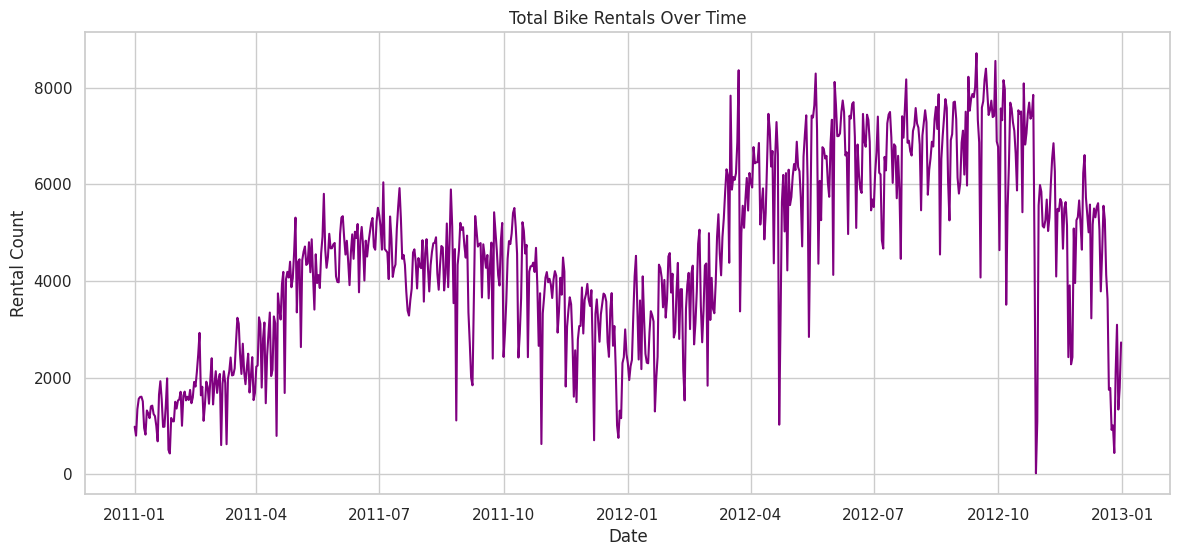

In [8]:

plt.figure(figsize=(14,6))
plt.plot(pd.to_datetime(df['dteday']), df['cnt'], color='purple')
plt.title("Total Bike Rentals Over Time")
plt.xlabel("Date")
plt.ylabel("Rental Count")
plt.show()

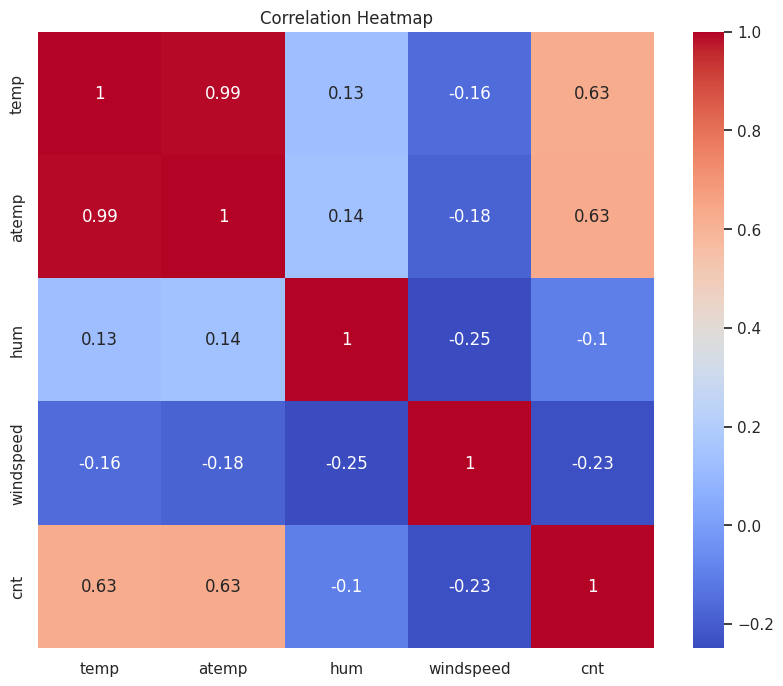

In [9]:

# Correlation matrix for numeric features
plt.figure(figsize=(10, 8))
corr_matrix = df[['temp', 'atemp', 'hum', 'windspeed', 'cnt']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', square=True)
plt.title("Correlation Heatmap")
plt.show()

<ipython-input-10-0e56647dfa04>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='season', y='cnt', palette='Set2')


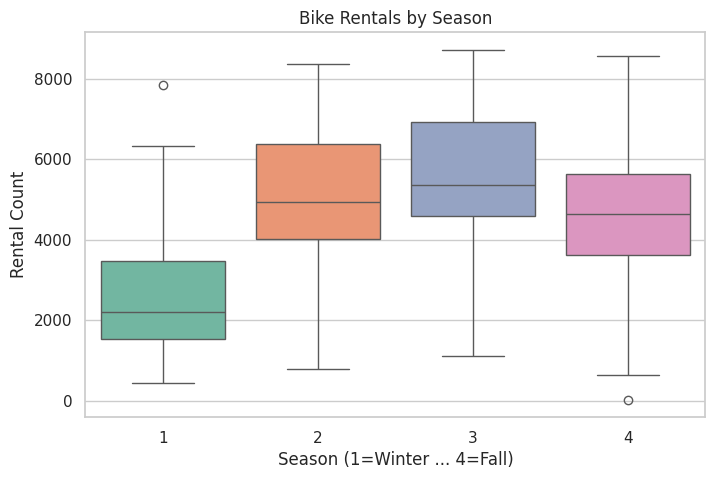

In [10]:

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='season', y='cnt', palette='Set2')
plt.title("Bike Rentals by Season")
plt.xlabel("Season (1=Winter ... 4=Fall)")
plt.ylabel("Rental Count")
plt.show()

<ipython-input-11-14817a5a2124>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='workingday', y='cnt', palette='Set3')


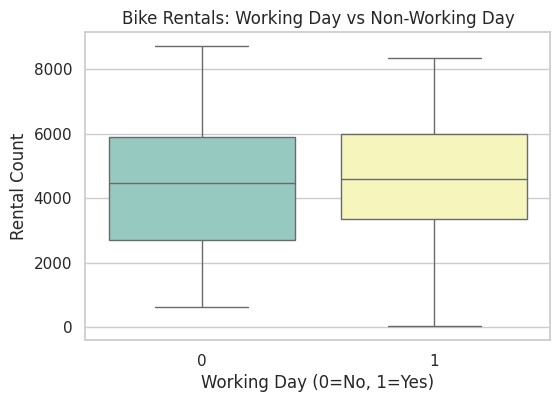

In [11]:

plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='workingday', y='cnt', palette='Set3')
plt.title("Bike Rentals: Working Day vs Non-Working Day")
plt.xlabel("Working Day (0=No, 1=Yes)")
plt.ylabel("Rental Count")
plt.show()

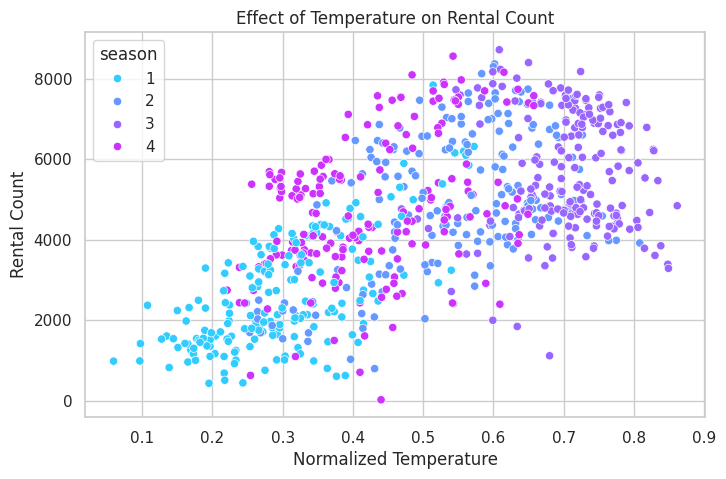

In [12]:

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='temp', y='cnt', hue='season', palette='cool')
plt.title("Effect of Temperature on Rental Count")
plt.xlabel("Normalized Temperature")
plt.ylabel("Rental Count")
plt.show()

<ipython-input-13-a84e1daa77fd>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly = df.groupby('mnth')['cnt'].mean().reset_index()
<ipython-input-13-a84e1daa77fd>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly, x='mnth', y='cnt', palette='viridis')


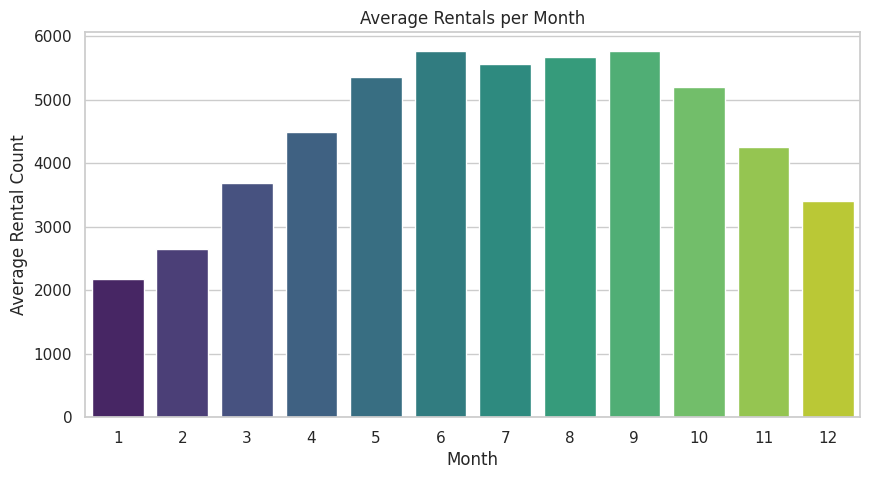

In [13]:

monthly = df.groupby('mnth')['cnt'].mean().reset_index()
plt.figure(figsize=(10, 5))
sns.barplot(data=monthly, x='mnth', y='cnt', palette='viridis')
plt.title("Average Rentals per Month")
plt.xlabel("Month")
plt.ylabel("Average Rental Count")
plt.show()

In [14]:

df['date'] = pd.to_datetime(df['dteday'])
df['dayofweek'] = df['date'].dt.dayofweek
df['is_weekend'] = df['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

In [15]:

df_model = df.copy()
df_model = pd.get_dummies(df_model, columns=[
    'season', 'weathersit', 'mnth', 'weekday', 'dayofweek'
], drop_first=True)

In [16]:

df_model = df_model.drop(['dteday', 'date'], axis=1)

X = df_model.drop(['cnt'], axis=1)
y = df_model['cnt']

In [17]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = {"MSE": mse, "R2 Score": r2}
    print(f"{name} => MSE: {mse:.2f}, R2 Score: {r2:.4f}")

Linear Regression => MSE: 634351.36, R2 Score: 0.8418
Random Forest => MSE: 522143.71, R2 Score: 0.8698
Gradient Boosting => MSE: 480508.55, R2 Score: 0.8802


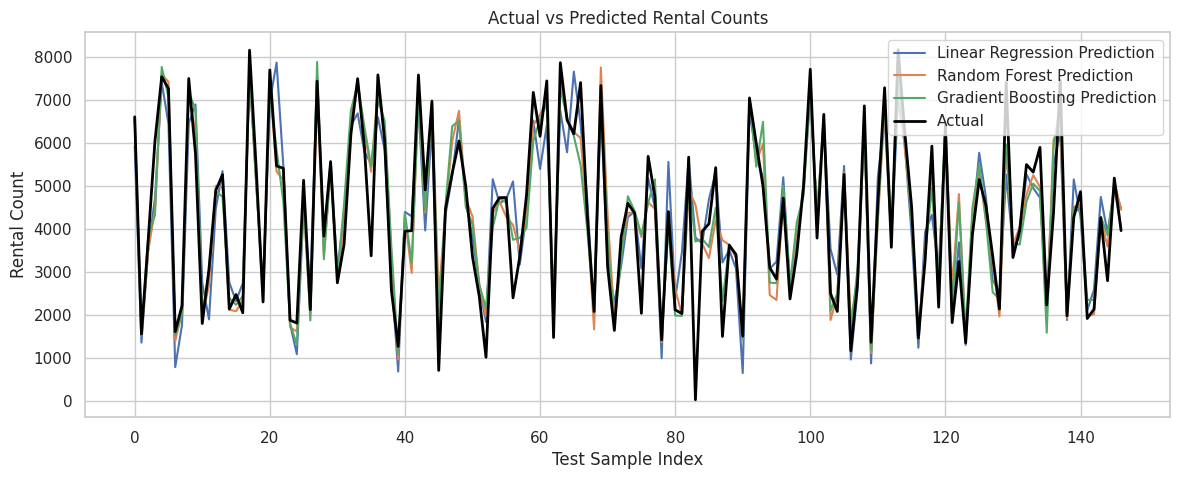

In [19]:

plt.figure(figsize=(14, 5))
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    plt.plot(range(len(y_pred)), y_pred, label=f"{name} Prediction")
plt.plot(range(len(y_test)), y_test.values, label='Actual', color='black', linewidth=2)
plt.legend()
plt.title("Actual vs Predicted Rental Counts")
plt.xlabel("Test Sample Index")
plt.ylabel("Rental Count")
plt.show()

<ipython-input-20-0f6c04ab201c>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=result_df, x='Model', y='MSE', ax=ax[0], palette='Set1')
<ipython-input-20-0f6c04ab201c>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=result_df, x='Model', y='R2 Score', ax=ax[1], palette='Set2')


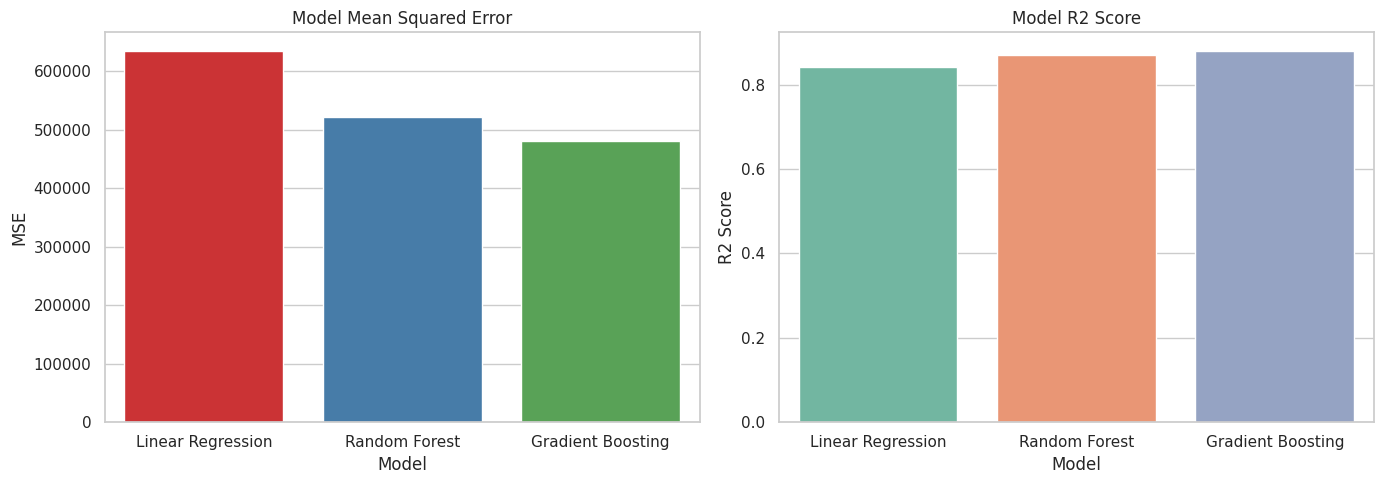

In [20]:

result_df = pd.DataFrame(results).T.reset_index().rename(columns={"index": "Model"})

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=result_df, x='Model', y='MSE', ax=ax[0], palette='Set1')
ax[0].set_title("Model Mean Squared Error")

sns.barplot(data=result_df, x='Model', y='R2 Score', ax=ax[1], palette='Set2')
ax[1].set_title("Model R2 Score")

plt.tight_layout()
plt.show()

In [21]:

import joblib

best_model = models["Gradient Boosting"]
joblib.dump(best_model, "bike_rental_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [22]:

# Load model
loaded_model = joblib.load("bike_rental_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")

# Predict using new data
sample = X_test.iloc[0:1]
scaled_sample = loaded_scaler.transform(sample)
prediction = loaded_model.predict(scaled_sample)

print(f"Predicted rentals: {prediction[0]:.2f}")

Predicted rentals: 6587.76
